# 실험 1: Diffusion 오버샘플링, DDPM T=1000 학습 + 샘플링 스텝만 줄이기 (10/20/30/100/300/1000스텝)

In [22]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = list(range(10))  # seed 0~9 전부

  GPU 0: memory 16812 MiB, util 83%
  GPU 1: memory 8000 MiB, util 0%
  GPU 2: memory 0 MiB, util 0%
사용 GPU: 2


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))
print("공용 모듈 경로:", _d)

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_group_split, crop_group, CachedDataset, CachedSubset, BalancedDataset,
    generate_balanced_fake, draw_from_pool,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


공용 모듈 경로: 7_diffusion_image_filter
device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [25]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/AM_image_data_3split")  # 원본 213x460 (한 장을 3조각 낸 k0/k1/k2) → 아래 transform에서 64x64로 resize

RESUME = False
RESULTS_CSV = "exp1_oversampling.csv"
if not RESUME and os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_group_split(full_dataset, train_counts, test_counts, seed=seed)
    leaked = ({crop_group(full_dataset.samples[i][0]) for i in train_indices}
              & {crop_group(full_dataset.samples[i][0]) for i in test_indices})
    assert not leaked, f"같은 원본이 train/test에 모두 있음: {sorted(leaked)[:5]}"

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


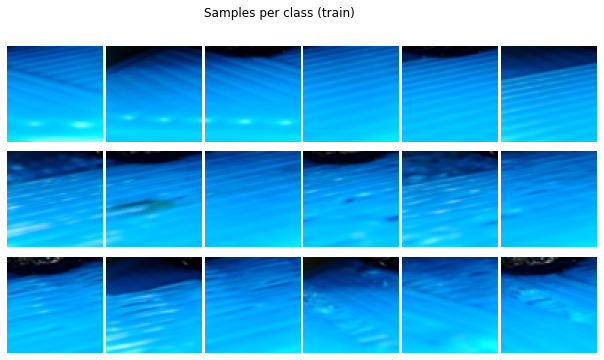

In [26]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. Diffusion / 평가 공통 유틸

In [27]:
timesteps = 1000
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)
SAMPLE_STEPS = [10, 20, 30, 100, 300, 1000]

print("diffusion/평가 유틸 정의 완료")



CLASSIFIER_EPOCHS_REF = 100
CLASSIFIER_LR = 2e-4
CLASSIFIER_BETAS = (0.5, 0.9)
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")

DIFFUSION_EPOCHS_REF = 500
EMA_DECAY = 0.999


def train_classifier_for_steps(loader, total_steps, seed, tag="Classifier"):
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels, image_size=image_size).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=CLASSIFIER_LR, betas=CLASSIFIER_BETAS)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(loader)
    losses = []
    pbar = tqdm(range(total_steps), desc=f"[{tag} seed{seed}] steps", leave=False)
    t0 = time.time()

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y = next(data_iter)

        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = classifier(x)
        loss = cls_loss_fn(logits, y)

        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        pbar.set_postfix(cls=f"{loss.item():.4f}")

        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            print(f"[{tag} seed{seed}] step {step+1}/{total_steps} Cls={np.mean(losses[-50:]):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return classifier


diffusion/평가 유틸 정의 완료
분류기 학습 기준 step 수 (BASELINE_STEPS) = 24 batches/epoch x 100 epochs = 2400


## 실험 1: Diffusion 오버샘플링 (DDPM T=1000 학습, respacing 10/20/30/100/300/1000스텝 fake 풀)

In [28]:
def train_diffusion(seed, epochs=None):
    epochs = epochs or DIFFUSION_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Diffusion seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)

            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")

        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Diffusion seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema


def train_classifier_on(dataset, seed, total_steps=None):
    total_steps = total_steps or BASELINE_STEPS
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                         pin_memory=(DEVICE == "cuda"))
    return train_classifier_for_steps(loader, total_steps, seed, tag="Classifier")


DIFFUSION_PATH = "checkpoints/exp1_ddpm1000_diffusion_seed{seed}.pt"
DIFFUSION_EMA_PATH = "checkpoints/exp1_ddpm1000_diffusion_ema_seed{seed}.pt"
os.makedirs("checkpoints", exist_ok=True)


def load_or_train_diffusion(seed):
    path, ema_path = DIFFUSION_PATH.format(seed=seed), DIFFUSION_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        print(f"[Diffusion seed{seed}] 학습 건너뜀: {path}, {ema_path} 로드")
        return diffusion, ema, False
    diffusion, ema = train_diffusion(seed)
    return diffusion, ema, True


In [29]:
POOL_PER_CLASS = 800 - 80
POOL_GEN_BATCH = 360  # 한 번의 샘플링 호출로 생성할 장 수 (클래스당 2번 호출)


def build_pool(seed, gen_model, steps, minority_classes=(1, 2)):
    set_seed(seed)  # 스텝 수가 달라도 같은 seed의 초기 노이즈에서 출발한다
    t0 = time.time()
    pool = generate_balanced_fake(ddpm, gen_model, DEVICE, steps, target_per_class=POOL_PER_CLASS, minority_classes=minority_classes,
                                  batch_size=POOL_GEN_BATCH)
    print(f"[Pool step{steps} seed{seed}] 클래스당 {POOL_PER_CLASS}장 생성 완료: {time.time()-t0:.1f}초")
    return {cls: x.to(DEVICE) for cls, x in pool.items()}


def train_classifier_pool(seed, pool, total_steps=None, tag="Classifier-pool"):
    total_steps = total_steps or BASELINE_STEPS
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels, image_size=image_size).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=CLASSIFIER_LR, betas=CLASSIFIER_BETAS)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(train_loader)
    losses = []
    t0 = time.time()
    pbar = tqdm(range(total_steps), desc=f"[{tag} seed{seed}]")

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x, y = next(data_iter)
        x, y = x.to(device), y.to(device)

        x_fake, y_fake = draw_from_pool(pool, y, device)
        if x_fake is not None:
            x = torch.cat([x, x_fake], dim=0)
            y = torch.cat([y, y_fake], dim=0)

        loss = cls_loss_fn(classifier(x), y)
        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        if (step + 1) % 50 == 0:
            pbar.set_postfix(cls=f"{np.mean(losses[-50:]):.4f}")
        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            tqdm.write(f"[{tag} seed{seed}] step {step+1}/{total_steps} "
                       f"Cls={np.mean(losses[-50:]):.4f} elapsed={time.time()-t0:.1f}s")

    return classifier


pool_rows = []
pool_models = {}  # 미리보기용 EMA 모델

done = set()
if RESUME and os.path.exists(RESULTS_CSV):
    _prev = pd.read_csv(RESULTS_CSV)
    done = set(zip(_prev["method"], _prev["seed"]))
    print(f"[Resume] 이미 끝난 (method, seed) {len(done)}개는 건너뜀")

for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Diffusion oversampling (DDPM T={timesteps}, respacing {SAMPLE_STEPS}) | Seed {seed} =====")
    diffusion, ema, trained = load_or_train_diffusion(seed)
    if trained:
        torch.save(diffusion.state_dict(), DIFFUSION_PATH.format(seed=seed))
        torch.save(ema.model.state_dict(), DIFFUSION_EMA_PATH.format(seed=seed))
    pool_models[seed] = ema.model

    for steps in SAMPLE_STEPS:
        method = f"1_diffusion_oversampling_ddpm1000_step{steps}"
        if (method, seed) in done:
            print(f"[Exp1 step{steps} seed{seed}] 결과 있음 → 건너뜀")
            continue
        t0 = time.time()
        pool = build_pool(seed, ema.model, steps)
        classifier = train_classifier_pool(seed, pool, tag=f"Classifier-step{steps}")
        print(f"[Exp1 step{steps} seed{seed}] 총 소요 시간: {time.time()-t0:.1f}초")

        metrics = evaluate_classifier(classifier, test_loader, DEVICE, num_classes, CLASS_NAMES)
        rows = metrics_to_rows(metrics, seed, method)
        pool_rows.extend(rows)
        append_result_rows(rows, RESULTS_CSV)
        del pool

df_pool = pd.DataFrame(pool_rows)

def seed_summary(df):
    cols = ["precision", "recall", "f1", "accuracy"]
    d = df.assign(**{"class": df["class"].astype(str).replace({str(i): n for i, n in enumerate(CLASS_NAMES)})})
    g = d.groupby(["method", "class"], sort=False)[cols]
    out = g.mean().applymap("{:.3f}".format) + " ± " + g.std(ddof=1).applymap("{:.3f}".format)
    out.insert(0, "n_seeds", g.size())
    return out


display(df_pool)
_df = pd.read_csv(RESULTS_CSV)
_order = {s: i for i, s in enumerate(SAMPLE_STEPS)}
_df = _df.assign(_s=_df["method"].str.extract(r"step(\d+)$")[0].astype(int).map(_order))
_df.sort_values(["_s", "seed"], kind="mergesort").drop(columns="_s").to_csv(RESULTS_CSV, index=False)

df_all_runs = pd.read_csv(RESULTS_CSV).drop_duplicates(subset=["method", "seed", "class"], keep="last")
print(f"\n===== seed {df_all_runs['seed'].nunique()}개 평균 ± 표준편차 (CSV 전체) =====")
seed_summary(df_all_runs)


[Diffusion seed6]:  20%|██        | 100/500 [06:51<28:09,  4.22s/it, diff=0.0071]

[Diffusion seed6] Epoch 100/500 Diff=0.0071 elapsed=411.8s


[Diffusion seed6]:  40%|████      | 200/500 [13:36<20:32,  4.11s/it, diff=0.0078]

[Diffusion seed6] Epoch 200/500 Diff=0.0078 elapsed=816.5s


[Diffusion seed6]:  60%|██████    | 300/500 [20:23<13:43,  4.12s/it, diff=0.0035]

...

[Classifier-step1000 seed9]: 100%|██████████| 2400/2400 [00:09<00:00, 250.19it/s, cls=0.1792]

[Classifier-step1000 seed9] step 2400/2400 Cls=0.1792 elapsed=9.6s
[Exp1 step1000 seed9] 총 소요 시간: 485.1초
===== Evaluation =====
Accuracy        : 0.8767
Precision(macro): 0.8842
Recall(macro)   : 0.8767
F1(macro)       : 0.8728

Per-class:
Class Normal | P:0.808 R:0.970 F1:0.882 N:100
Class Underfill_50FR | P:0.921 R:0.700 F1:0.795 N:100
Class Underfill_Fan | P:0.923 R:0.960 F1:0.941 N:100

Confusion Matrix:
 [[97  2  1]
 [23 70  7]
 [ 0  4 96]]


,method,seed,class,precision,recall,f1,support,accuracy
0,1_diffusion_oversampling_ddpm1000_step10,0,0,0.800000,0.600000,0.685714,100,0.780000
1,1_diffusion_oversampling_ddpm1000_step10,0,1,0.658730,0.830000,0.734513,100,0.780000
2,1_diffusion_oversampling_ddpm1000_step10,0,2,0.919192,0.910000,0.914573,100,0.780000
3,1_diffusion_oversampling_ddpm1000_step10,0,macro,0.792641,0.780000,0.778267,300,0.780000
4,1_diffusion_oversampling_ddpm1000_step20,0,0,0.590361,0.980000,0.736842,100,0.753333
...,...,...,...,...,...,...,...,...
235,1_diffusion_oversampling_ddpm1000_step300,9,macro,0.881058,0.873333,0.870533,300,0.873333
236,1_diffusion_oversampling_ddpm1000_step1000,9,0,0.808333,0.970000,0.881818,100,0.876667
237,1_diffusion_oversampling_ddpm1000_step1000,9,1,0.921053,0.700000,0.795455,100,0.876667
238,1_diffusion_oversampling_ddpm1000_step1000,9,2,0.923077,0.960000,0.941176,100,0.876667



===== seed 10개 평균 ± 표준편차 (CSV 전체) =====


n_seeds  \
method                                     class                     
1_diffusion_oversampling_ddpm1000_step10   Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   
1_diffusion_oversampling_ddpm1000_step20   Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   
1_diffusion_oversampling_ddpm1000_step30   Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   
1_diffusion_oversampling_ddpm1000_step100  Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   
1_diffusion_oversampling_ddpm1000_step300  Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   
1_diffusion_oversampling_ddpm1000_step1000 Normal               10   
                                           Underfill_50FR       10   
                                           Underfill_Fan        10   
                                           macro                10   

                                                               precision  \
method                                     class                           
1_diffusion_oversampling_ddpm1000_step10   Normal          0.671 ± 0.116   
                                           Underfill_50FR  0.857 ± 0.085   
                                           Underfill_Fan   0.939 ± 0.020   
                                           macro           0.822 ± 0.043   
1_diffusion_oversampling_ddpm1000_step20   Normal          0.696 ± 0.085   
                                           Underfill_50FR  0.878 ± 0.056   
                                           Underfill_Fan   0.953 ± 0.015   
                                           macro           0.842 ± 0.034   
1_diffusion_oversampling_ddpm1000_step30   Normal          0.751 ± 0.093   
                                           Underfill_50FR  0.855 ± 0.093   
                                           Underfill_Fan   0.933 ± 0.022   
                                           macro           0.846 ± 0.040   
1_diffusion_oversampling_ddpm1000_step100  Normal          0.781 ± 0.081   
                                           Underfill_50FR  0.869 ± 0.052   
                                           Underfill_Fan   0.948 ± 0.029   
                                           macro           0.866 ± 0.023   
1_diffusion_oversampling_ddpm1000_step300  Normal          0.774 ± 0.102   
                                           Underfill_50FR  0.880 ± 0.068   
                                           Underfill_Fan   0.945 ± 0.024   
                                           macro           0.866 ± 0.035   
1_diffusion_oversampling_ddpm1000_step1000 Normal          0.796 ± 0.078   
                                           Underfill_50FR  0.854 ± 0.103   
                                           Underfill_Fan   0.939 ± 0.020   
                                           macro           0.863 ± 0.037   

                                                                  recall  \
method                                     class                           
1_diffusion_oversampling_ddpm1000_step10   Normal          0.916 ± 0.120   
                                 

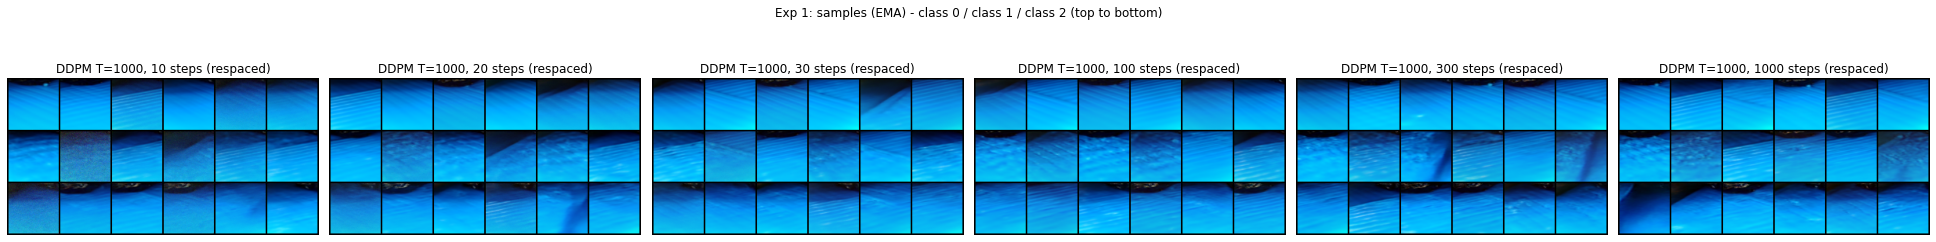

: 

In [31]:
seed_to_show = SEEDS[0]
diffusion = pool_models[seed_to_show]
y_vis = torch.tensor([0] * 6 + [1] * 6 + [2] * 6, device=DEVICE)
fig, axes = plt.subplots(1, len(SAMPLE_STEPS), figsize=(4.5 * len(SAMPLE_STEPS), 4.0))
for ax, steps in zip(np.atleast_1d(axes), SAMPLE_STEPS):
    set_seed(seed_to_show)
    x_vis = ddpm.sample_ddpm_respaced(diffusion, y_vis, DEVICE, steps=steps)
    grid = make_grid(denorm(x_vis).clamp(0, 1).cpu(), nrow=6)
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"DDPM T={timesteps}, {steps} steps (respaced)")
plt.suptitle("Exp 1: samples (EMA) - class 0 / class 1 / class 2 (top to bottom)")
plt.tight_layout()
plt.show()
